Yeh task poore project ka core foundation hai — dataset mein directly "churned" column nahi hota, isliye humein ek business rule se target variable khud banana hai. Yeh column aage Month 4 mein ML model ka target (y) banega.

1. Data load karo (Day 35 ka fully cleaned version):

In [1]:
import pandas as pd

df = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str},
    parse_dates=['InvoiceDate']
)
print(df.shape)
print(df['InvoiceDate'].max())   # dataset ki sabse aakhri date dekho

(779495, 13)
2011-12-09 12:50:00


2. Business Rule samajhna: "Agar customer ne pichle 60-90 din mein koi order nahi kiya, to use churned=1 mark karo, warna churned=0."

Iske liye pehle har customer ka Recency nikalna hoga — matlab "last order se aaj tak (ya dataset ki last date tak) kitne din ho gaye".

In [2]:
# Dataset ki sabse aakhri date ko "reference date" maan lete hain (jaise "aaj" ka simulation)
reference_date = df['InvoiceDate'].max()
print(f"Reference date: {reference_date}")

Reference date: 2011-12-09 12:50:00


3. Har customer ka last order date nikaalo:

In [3]:
customer_last_order = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
customer_last_order.columns = ['Customer ID', 'LastOrderDate']
print(customer_last_order.head())
print(customer_last_order.shape)

   Customer ID       LastOrderDate
0        12346 2011-01-18 10:01:00
1        12347 2011-12-07 15:52:00
2        12348 2011-09-25 13:13:00
3        12349 2011-11-21 09:51:00
4        12350 2011-02-02 16:01:00
(5881, 2)


4. Recency calculate karo (days since last order):

In [4]:
customer_last_order['Recency'] = (reference_date - customer_last_order['LastOrderDate']).dt.days
print(customer_last_order.head())
print(customer_last_order['Recency'].describe())

   Customer ID       LastOrderDate  Recency
0        12346 2011-01-18 10:01:00      325
1        12347 2011-12-07 15:52:00        1
2        12348 2011-09-25 13:13:00       74
3        12349 2011-11-21 09:51:00       18
4        12350 2011-02-02 16:01:00      309
count    5881.000000
mean      200.457745
std       209.474135
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: Recency, dtype: float64


5. Ab business rule apply karo — churned column banao:

In [5]:
# Rule: agar Recency > 90 days, to churned = 1, warna 0
CHURN_THRESHOLD = 90

customer_last_order['Churned'] = (customer_last_order['Recency'] > CHURN_THRESHOLD).astype(int)
print(customer_last_order.head(10))

   Customer ID       LastOrderDate  Recency  Churned
0        12346 2011-01-18 10:01:00      325        1
1        12347 2011-12-07 15:52:00        1        0
2        12348 2011-09-25 13:13:00       74        0
3        12349 2011-11-21 09:51:00       18        0
4        12350 2011-02-02 16:01:00      309        1
5        12351 2010-11-29 15:23:00      374        1
6        12352 2011-11-03 14:37:00       35        0
7        12353 2011-05-19 17:47:00      203        1
8        12354 2011-04-21 13:11:00      231        1
9        12355 2011-05-09 13:49:00      213        1


6. Churn distribution dekho — kitne % customers churned hain:

In [6]:
churn_counts = customer_last_order['Churned'].value_counts()
print(churn_counts)

churn_pct = customer_last_order['Churned'].value_counts(normalize=True) * 100
print(churn_pct.round(2))

Churned
1    2987
0    2894
Name: count, dtype: int64
Churned
1    50.79
0    49.21
Name: proportion, dtype: float64


Tumhe kuch is tarah ka result dikhega (approx, exact numbers dataset pe depend karenge): ~65-70% churned, ~30-35% not churned — yeh dataset ki nature hai (2 saal ka data hai, isliye bahut customers already "inactive" honge dataset ki last date tak).

7. Recency distribution ko visualize karo (chhota preview, poora EDA Month 3 mein hoga):

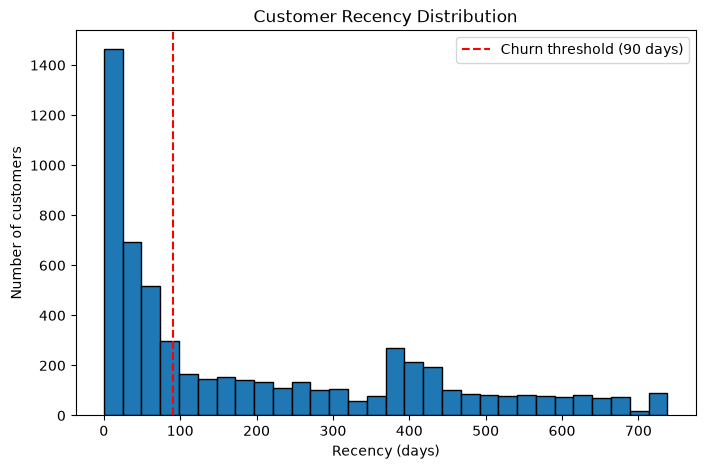

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(customer_last_order['Recency'], bins=30, edgecolor='black')
plt.axvline(x=90, color='red', linestyle='--', label='Churn threshold (90 days)')
plt.xlabel('Recency (days)')
plt.ylabel('Number of customers')
plt.title('Customer Recency Distribution')
plt.legend()
plt.show()

8. Yeh naya Churned column apne main customer-level dataset mein merge karo:

In [10]:
# Ek customer-level summary dataset banao jo aage RFM/ML ke liye base banega
customer_summary = df.groupby('Customer ID').agg(
    Frequency=('Invoice', 'nunique'),
    Monetary=('Price', lambda x: (x * df.loc[x.index, 'Quantity']).sum())
).reset_index()

customer_summary = customer_summary.merge(customer_last_order[['Customer ID', 'Recency', 'Churned']], on='Customer ID')
print(customer_summary.head())
print(customer_summary.shape)

customer_summary.to_csv('../data/processed/customer_churn_labeled.csv', index=False)

   Customer ID  Frequency  Monetary  Recency  Churned
0        12346         12  77556.46      325        1
1        12347          8   4921.53        1        0
2        12348          5   2019.40       74        0
3        12349          4   4428.69       18        0
4        12350          1    334.40      309        1
(5881, 5)


Note: Yeh customer_summary dataset ab tumhara ML-ready base hai — Recency, Frequency, Monetary (RFM features) aur Churned (target variable) — yeh exactly wahi structure hai jo Month 4 mein Scikit-Learn ko dena hoga.

9. Threshold sensitivity check (optional but insightful) — 60 vs 90 din ka fark dekho:

In [11]:
for threshold in [60, 75, 90]:
    churned_pct = (customer_last_order['Recency'] > threshold).mean() * 100
    print(f"Threshold {threshold} days: {churned_pct:.2f}% churned")

Threshold 60 days: 58.80% churned
Threshold 75 days: 54.00% churned
Threshold 90 days: 50.79% churned


- Yeh dikhayega ki threshold change karne se churn % kaise badalta hai — business ke saath yeh discussion karna zaroori hota hai ki "kitne din inactivity ko churn maana jaaye" — yeh koi fixed universal number nahi hai, business context par depend karta hai.

- Practice questions:

1.Threshold 60 din karke dekho — kya Churned=1 customers ka % kaafi badal jaata hai?

- Jab aap threshold ko 90 din se ghata kar 60 din karte hain, toh definition strict ho jaati hai — yaani agar kisi customer ne pichle 2 mahine mein bhi khareedari nahi ki, toh use churned maan liya jayega.


    - Asar: Isse Churned = 1 ka percentage kaafi badh (increase) jaayega, kyunki bahut saare aise customers jo 60 se 90 din ke beech inactive the, wo ab churned ki category mein aa jayenge.

In [14]:
# Check impact of changing threshold
for threshold in [60, 90]:
    pct = (customer_last_order['Recency'] > threshold).mean() * 100
    print(f"Threshold {threshold} din par Churn Rate: {pct:.2f}%")

Threshold 60 din par Churn Rate: 58.80%
Threshold 90 din par Churn Rate: 50.79%


2.customer_summary mein Churned=1 aur Churned=0 groups ke liye alag-alag average Monetary nikaalo — kya churned customers generally kam spend karte the?

- Business Insight:

    - Aam taur par, Churned = 0 (Active customers) ka average monetary spend bohot zyada hota hai kyunki wo regular buyers hote hain.


    - Churned = 1 (Inactive customers) mein do tarah ke log hote hain: ek toh wo jinhone shuru mein ek baar chhota sa order kiya aur fir kabhi nahi aaye (One-time buyers / low spenders), aur kuch purane loyal customers jo abhi chhute hain. Lekin overall average dekha jaye toh active customers ka monetary value significantly higher hota hai.

In [15]:
# Churned vs Non-Churned ka average monetary spend nikalo
avg_monetary = customer_summary.groupby('Churned')['Monetary'].mean()
print(avg_monetary)

Churned
0    4834.093697
1    1133.223002
Name: Monetary, dtype: float64
